# Optuna Parameter Calibration: Return vs Dynamic Risk Control

This notebook reads a completed `trial_metrics.csv` generated by `scripts.optimization.optuna_calibration`. It does **not** rerun the expensive portfolio simulations. The analysis compares a maximum-return policy with a return-constrained risk-control policy and studies stable parameter ranges.

In [9]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from scripts.optimization.analysis import (
    add_policy_scores, build_parameter_range_summary, choose_policy_trials,
    extract_pareto_front, policy_comparison_table,
)

TRIAL_METRICS = ROOT / 'results/calibration/advanced_smart_bayesian_risk_return/trial_metrics.csv'
assert TRIAL_METRICS.exists(), f'Run the Optuna calibration first: {TRIAL_METRICS}'
trials = add_policy_scores(pd.read_csv(TRIAL_METRICS))
completed = trials[trials['status'].astype(str).str.upper().eq('COMPLETE')].copy()
completed.head()


,trial_number,status,datetime_start,datetime_complete,duration_seconds,param_optimizer.0.max_weight,param_optimizer.0.turnover_penalty,param_optimizer.0.confidence_level,param_optimizer.0.cvar_budget_mult,param_model.prior_strength,...,sharpe_ratio,sortino_ratio,turnover,win_rate,objective_0,objective_1,objective_2,objective_3,return_policy_score,risk_control_score
1,1,COMPLETE,2026-07-30 02:45:15.191205,2026-07-30 02:52:41.813429,446.622224,0.10,0.006978,0.900,0.75,126.0,...,1.156141,2.240414,0.01,0.68,0.262092,0.202923,0.123009,0.090225,0.544603,-0.055546
2,2,COMPLETE,2026-07-30 02:52:41.878530,2026-07-30 03:00:02.062543,440.184013,0.09,0.002142,0.975,0.90,63.0,...,1.213143,2.373180,0.01,0.68,0.261093,0.190896,0.110555,0.084405,0.605531,0.129171
3,3,COMPLETE,2026-07-30 03:00:02.129371,2026-07-30 03:15:02.731165,900.601794,0.06,0.006943,0.900,1.10,63.0,...,1.382761,3.004950,0.01,0.72,0.219504,0.136636,0.069370,0.057024,0.084133,0.643029
4,4,COMPLETE,2026-07-30 03:15:02.792341,2026-07-30 11:18:12.901509,28990.109168,0.12,0.000835,0.900,1.05,126.0,...,1.226078,2.236387,0.01,0.80,0.141264,0.095631,0.071231,0.044666,-1.610327,0.112798
5,5,COMPLETE,2026-07-30 11:18:12.969093,2026-07-30 11:31:44.936128,811.967035,0.09,0.002251,0.990,1.15,42.0,...,1.156935,2.259133,0.01,0.72,0.136033,0.097460,0.068001,0.044044,-1.750930,0.057202


## 1. Select the two policies

The maximum-return configuration answers the profit-seeking question. The risk-control configuration must first pass a return floor, then maximizes a robust utility that rewards Sharpe, Sortino, PSR and DSR while penalizing volatility, drawdown, CVaR and turnover.

In [10]:
selected = choose_policy_trials(
    completed, return_floor_quantile=0.35, minimum_annual_return=0.05, minimum_dsr=0.50
)
comparison = policy_comparison_table(completed, selected)
comparison


,policy,trial_number,annualized_return,annualized_volatility,sharpe_ratio,sortino_ratio,max_drawdown,cvar_95,downside_deviation,psr,dsr,turnover,return_policy_score,risk_control_score,parameters
0,max_return,23,0.277135,0.185271,1.313352,2.822778,-0.098217,-0.074346,0.091093,0.962914,0.644524,0.01,1.046289,0.486827,"{""backtest_engine.degradation_penalty"": 0.55, ..."
1,risk_control,50,0.266670,0.160889,1.435435,3.254797,-0.084181,-0.057111,0.075787,0.974509,0.730247,0.01,1.057424,0.856269,"{""backtest_engine.degradation_penalty"": 0.55, ..."


## 2. Return-risk frontier

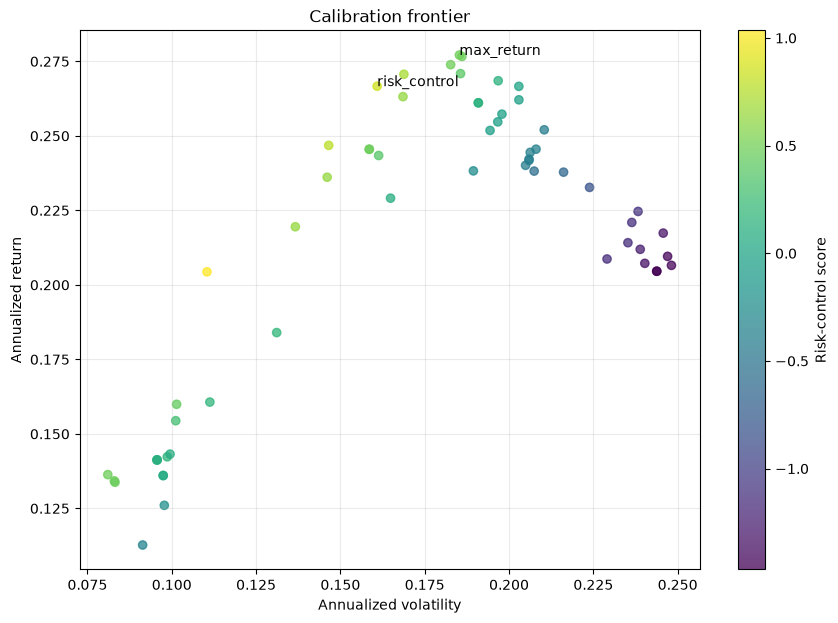

In [11]:
fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(
    completed['annualized_volatility'], completed['annualized_return'],
    c=completed['risk_control_score'], cmap='viridis', alpha=0.75
)
for label, row in selected.items():
    ax.annotate(label, (row['annualized_volatility'], row['annualized_return']))
ax.set_xlabel('Annualized volatility')
ax.set_ylabel('Annualized return')
ax.set_title('Calibration frontier')
ax.grid(alpha=0.25)
fig.colorbar(scatter, ax=ax, label='Risk-control score')
plt.show()


## 3. Parameter ranges and metric response

In [12]:
ranges = build_parameter_range_summary(completed, max_bins=6, top_fraction=0.20)
ranges.head(20)


,parameter,range,n_trials,top_risk_control_share,median_annualized_return,mean_annualized_return,q25_annualized_return,q75_annualized_return,median_annualized_volatility,mean_annualized_volatility,...,q25_psr,q75_psr,median_dsr,mean_dsr,q25_dsr,q75_dsr,median_risk_control_score,mean_risk_control_score,q25_risk_control_score,q75_risk_control_score
0,backtest_engine.degradation_penalty,"(-0.001, 0.05]",12,0.083333,0.215765,0.208689,0.190605,0.244601,0.201904,0.183070,...,0.875576,0.944071,0.541799,0.525675,0.415145,0.587787,-0.222756,-0.367768,-1.150269,0.080514
1,backtest_engine.degradation_penalty,"(0.05, 0.367]",8,0.000000,0.151950,0.168869,0.141264,0.189636,0.105393,0.137601,...,0.927760,0.942765,0.584522,0.547979,0.548235,0.588800,0.112798,-0.183532,-0.139925,0.127205
2,backtest_engine.degradation_penalty,"(0.367, 0.55]",24,0.208333,0.241324,0.219612,0.192043,0.267127,0.185443,0.172590,...,0.913915,0.959933,0.590412,0.559571,0.510707,0.634834,0.108582,-0.101576,-0.388565,0.409574
3,backtest_engine.degradation_penalty,"(0.55, 0.7]",9,0.555556,0.237826,0.233604,0.224645,0.245505,0.158557,0.170446,...,0.923597,0.965030,0.661070,0.611214,0.522334,0.676539,0.477157,0.173857,-0.361297,0.643029
4,backtest_engine.degradation_penalty,"(0.7, 0.75]",7,0.142857,0.240113,0.235874,0.229603,0.262623,0.202907,0.186648,...,0.921591,0.952463,0.570203,0.561327,0.526631,0.606420,-0.055546,-0.115307,-0.337352,0.214001
5,backtest_engine.stability_weight,"(-0.001, 0.2]",21,0.095238,0.224645,0.215430,0.154426,0.261093,0.190896,0.167818,...,0.923597,0.944840,0.584522,0.568456,0.522334,0.612402,0.112798,-0.056311,-0.361297,0.157393
6,backtest_engine.stability_weight,"(0.2, 0.4]",13,0.307692,0.237826,0.232192,0.211933,0.263153,0.206274,0.199420,...,0.873796,0.961835,0.509030,0.532496,0.416105,0.651793,-0.401628,-0.341970,-1.152260,0.485801
7,backtest_engine.stability_weight,"(0.4, 0.7]",18,0.222222,0.207076,0.199404,0.142010,0.244982,0.158557,0.155995,...,0.926920,0.959814,0.581729,0.566464,0.552110,0.651443,0.094190,-0.067207,-0.172987,0.453303
8,backtest_engine.stability_weight,"(0.7, 1.0]",8,0.250000,0.233639,0.218458,0.206615,0.248112,0.166841,0.169476,...,0.908936,0.950488,0.555842,0.561932,0.492556,0.623233,-0.129759,-0.090485,-0.461030,0.315122
9,model.mom_tilt,"(-0.001, 0.05]",21,0.238095,0.142309,0.162830,0.136033,0.183997,0.098650,0.107896,...,0.938005,0.960196,0.602279,0.617834,0.584522,0.657685,0.170425,0.276409,0.087994,0.475037


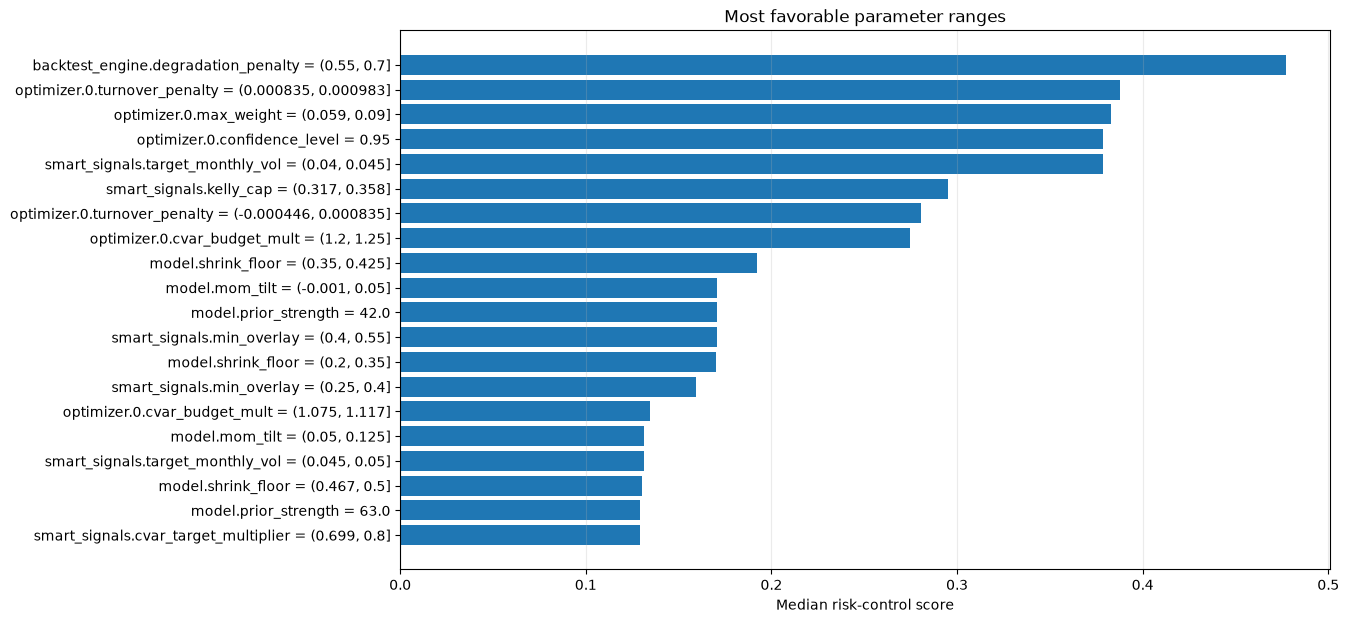

In [13]:
metric = 'median_risk_control_score'
top_ranges = ranges.sort_values(metric, ascending=False).head(20)
fig, ax = plt.subplots(figsize=(12, 7))
labels = top_ranges['parameter'] + ' = ' + top_ranges['range']
ax.barh(labels[::-1], top_ranges[metric][::-1])
ax.set_xlabel('Median risk-control score')
ax.set_title('Most favorable parameter ranges')
ax.grid(axis='x', alpha=0.25)
plt.show()


## 4. Pareto-efficient configurations

In [14]:
pareto = extract_pareto_front(completed)
pareto[[c for c in ['trial_number','annualized_return','annualized_volatility','max_drawdown','cvar_95','dsr'] if c in pareto]].head(20)


,trial_number,annualized_return,annualized_volatility,max_drawdown,cvar_95,dsr
0,23,0.277135,0.185271,-0.098217,-0.074346,0.644524
1,55,0.273887,0.182685,-0.098201,-0.073342,0.651793
2,53,0.270672,0.168818,-0.091394,-0.063550,0.686098
3,50,0.266670,0.160889,-0.084181,-0.057111,0.730247
4,21,0.246804,0.146525,-0.089430,-0.056268,0.716098
5,38,0.236121,0.146071,-0.079467,-0.060975,0.690329
6,3,0.219504,0.136636,-0.069370,-0.057024,0.676539
7,48,0.204381,0.110444,-0.051703,-0.042481,0.752332
8,59,0.159939,0.101429,-0.075161,-0.039696,0.638614
9,46,0.154426,0.101172,-0.079340,-0.043504,0.627670


## Interpretation checklist

A publishable calibration result should show: (i) a stable region rather than one isolated trial, (ii) a risk-control configuration that still clears the return floor, (iii) positive out-of-sample PSR/DSR evidence, and (iv) similar conclusions across adjacent parameter bins.